# Code walkthrough + inline tests: `python_version/`

This notebook walks through what each file in `python_version/` does, one module at a time, and exercises/tests it as it goes (every section ends with `assert` checks, not just prints). It's meant to be read top to bottom.

It complements two other things in this repo:
- `python_version/tests/*.py` — the automated `pytest` suite (`pytest` from the repo root). That's what should run in CI; this notebook is for humans to read and visualize.
- `documentation/database_structure_review.md` — the full severity-graded bug/design review this notebook's "Critical bug" sections demonstrate the fixes for.

**Model recap** (see `README.md`, `documentation/python_version_implementation_details.md`, and the papers in `papers/`): this simulates PRC1 crosslinker proteins binding to two antiparallel microtubules ("top" and "bottom"), each a 1D lattice of discrete binding sites, using the Gillespie stochastic simulation algorithm (SSA). A PRC1 can be unattached, singly attached (one head bound to one microtubule), or doubly attached (crosslinking both microtubules), and can diffuse ("hop") between adjacent sites.

In [1]:
import sys
import importlib.util
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

PYTHON_VERSION_DIR = Path.cwd().parent if Path.cwd().name == "tests" else Path.cwd()
if str(PYTHON_VERSION_DIR) not in sys.path:
    sys.path.insert(0, str(PYTHON_VERSION_DIR))

print("Working from:", PYTHON_VERSION_DIR)

Working from: /Users/tiffany/Documents/Research/Fall26-Kramer/prc-recruitment-bayesian-analysis-1/python_version


---
## 1. `prc1.py` — the `Prc1` class (one crosslinker "record")

Each `Prc1` instance represents one crosslinker molecule. It stores:
- `binding_site_top` / `binding_site_bottom` — the lattice site index each head is attached to, or `None` if that head is unattached. Setting these (e.g. `prc1.binding_site_top = 5`) automatically updates the parent `State`'s bookkeeping (occupancy sets, sorted lists) via a property setter -- an ORM-style "save on set" pattern implemented by hand.
- `closest_neighbor_left` / `closest_neighbor_right` — pointers to the nearest *doubly attached* neighboring PRC1, used to bound rate calculations.
- Status properties (`is_doubly_attached`, `is_singly_attached`, `is_unattached`, etc.) and rate properties (`attachment_rate`, `detachment_rate`, `*_hopping_rates`) computed on the fly from the object's state and its parent `State`'s physical constants.

Let's create a `State` (next section covers it in detail) and attach one `Prc1` to see these in action.

In [2]:
from prc1_state import State
from prc1 import Prc1

DEMO_PARAMS = dict(
    microtubule_length=200.0,
    site_spacing=1.0,
    microtubule_offset=50.0,
    spring_constant=2.0,
    rest_length=32.0,
    k_B_T=4.1,
    microtubule_separation=32.0,
    initial_binding_rate_per_site=0.05,
    singly_bound_detachment_rate=1.0,
    base_double_attachment_rate=10.0,
    base_double_detachment_rate=0.5,
    base_hopping_rate=1.0,
)

np.random.seed(0)
state = State(**DEMO_PARAMS)
print("empty state, num_prc1 =", state.num_prc1)
assert state.num_prc1 == 0

# a bare, unattached Prc1
prc1 = Prc1(state)
print("before attaching:", prc1, "is_unattached =", prc1.is_unattached)
assert prc1.is_unattached

# attach its bottom head to site 40 -- this is the property-setter "save on set" in action
prc1.binding_site_bottom = 40
prc1.set_closest_neighbors()
print("after attaching bottom head:", prc1, "is_singly_attached =", prc1.is_singly_attached)
assert prc1.is_singly_attached
assert 40 in state.bottom_taken_sites
assert state.num_prc1 == 1

empty state, num_prc1 = 0
before attaching: (None, None) is_unattached = True
after attaching bottom head: (40, None) is_singly_attached = True


### 1a. Critical bug #1 (fixed): `Prc1.__lt__`

`Prc1` objects are stored in `SortedSet`s, so Python needs `__lt__` to keep them ordered. The *old* implementation raised `RuntimeError` if either object being compared was fully unattached:
```python
if self.is_unattached or other.is_unattached:
    raise RuntimeError("error unbound comparing PRC", self, other)
```
`State.fast_hop()` (section 2c below) transiently constructs a `Prc1` and inserts it into a `SortedSet` *before* its first head is set in some code paths, which could hit this exact case and crash mid-simulation (a real, reproduced crash -- see `documentation/database_structure_review.md`, Critical finding #1). The fix makes `__lt__` tolerant of a transiently-unattached object instead of raising:
```python
if self.is_unattached or other.is_unattached:
    return not self.is_unattached
```
Section 2c demonstrates `fast_hop()` running crash-free across many seeds.

---
## 2. `prc1_state.py` — the `State` class (the "database")

`State` is the container for the whole simulated system:
- `top_taken_sites` / `bottom_taken_sites` (`SortedSetAndComplement`) — which lattice sites are occupied on each microtubule, plus their complement (untaken sites) and adjacency-to-occupied-site indices, all kept in sync automatically.
- `doubly_attached_prc1` / `top_attached_prc1` / `bottom_attached_prc1` (`SortedSet`s of `Prc1`) — the PRC1 population, split by attachment status.
- Methods that perform state transitions: `single_attach_prc1`, `double_attach_prc1`, `detach_prc1`, `hop_top`/`hop_bottom`, `fast_hop`.

### 2a. Attach / detach

In [3]:
np.random.seed(1)
state = State(**DEMO_PARAMS)

state.single_attach_prc1()
print("after single_attach_prc1():", state)
assert state.num_prc1 == 1

prc1 = state.get_prc1(0)
was_doubly_attached = False
if prc1.is_singly_attached and prc1.double_attachment_rate > 0:
    state.double_attach_prc1(0)
    was_doubly_attached = True
    print("after double_attach_prc1(0):", state)
    assert state.num_prc1 == 1 and len(state.doubly_attached_prc1) == 1

# detach_prc1 on a doubly-attached PRC1 only detaches ONE head per call
# (chosen randomly, weighted by each head's detachment rate), leaving it
# singly attached -- it does not remove the PRC1 outright. So fully clearing
# a doubly-attached PRC1 takes two detach_prc1 calls, not one.
state.detach_prc1(0)
if was_doubly_attached:
    print("after first detach_prc1(0) (now singly attached):", state)
    assert state.num_prc1 == 1
    state.detach_prc1(0)

print("after full detach:", state)
assert state.num_prc1 == 0
assert len(state.top_taken_sites) == 0 and len(state.bottom_taken_sites) == 0

after single_attach_prc1(): State(
doubly_attached_prc1 = SortedSet([])
top_attached_prc1 = SortedSet([])
bottom_attached_prc1 = SortedSet([(140, None)])
top_taken_sites = SortedSetAndComplement([])
bottom_taken_sites = SortedSetAndComplement([np.int64(140)])
)
after double_attach_prc1(0): State(
doubly_attached_prc1 = SortedSet([(140, 102)])
top_attached_prc1 = SortedSet([])
bottom_attached_prc1 = SortedSet([])
top_taken_sites = SortedSetAndComplement([np.int64(102)])
bottom_taken_sites = SortedSetAndComplement([np.int64(140)])
)
after first detach_prc1(0) (now singly attached): State(
doubly_attached_prc1 = SortedSet([])
top_attached_prc1 = SortedSet([(None, 102)])
bottom_attached_prc1 = SortedSet([])
top_taken_sites = SortedSetAndComplement([np.int64(102)])
bottom_taken_sites = SortedSetAndComplement([])
)
after full detach: State(
doubly_attached_prc1 = SortedSet([])
top_attached_prc1 = SortedSet([])
bottom_attached_prc1 = SortedSet([])
top_taken_sites = SortedSetAndComplement([])


### 2b. Cooperativity (nearest-neighbor binding-rate boost)

With `enable_cooperativity=True`, sites adjacent to an already-occupied site get a *higher* binding rate (`SortedSetAndComplement.single_adjacencies` / `double_adjacencies`, updated automatically on every add/remove). Note this is the opposite effect from "steric blocking" -- see `documentation/database_structure_review.md` High finding #5 for why the guideline's requested *distance-decaying, rate-reducing* steric interference is a distinct, not-yet-implemented feature from this cooperativity mechanism.

In [4]:
np.random.seed(2)
state = State(**{**DEMO_PARAMS, "enable_cooperativity": True, "cooperativity_energy": 10.0})

state.single_attach_prc1()
prc1 = state.get_prc1(0)
occupied_side = "bottom" if prc1.bottom_head_is_attached else "top"
occupied_site = prc1.binding_site_bottom if occupied_side == "bottom" else prc1.binding_site_top

adjacent_sites = getattr(state, f"{occupied_side}_singly_adjacent_sites")
print(f"occupied {occupied_side} site: {occupied_site}")
print(f"{occupied_side}_singly_adjacent_sites now includes neighbors:", sorted(adjacent_sites)[:6], "...")
assert (occupied_site - 1) in adjacent_sites or (occupied_site + 1) in adjacent_sites

occupied bottom site: 72
bottom_singly_adjacent_sites now includes neighbors: [np.int64(71), np.int64(73)] ...


### 2c. `fast_hop()` -- the fixed Critical bug, demonstrated live

`fast_hop()` detaches and reattaches every PRC1 head in random order each call, simulating fast diffusion. This is exactly the method that used to crash (saved traceback in the old `python_version/test.ipynb`). Running it repeatedly across many seeds here is the same regression check `test_gillespie.py::test_run_gillespie_prc1_on_grid_fast_hop_stress` and `test_state.py::test_fast_hop_regression_no_crash` make automatically -- if this cell raises, the bug has been reintroduced.

In [5]:
n_seeds = 25
failures = []
for seed in range(n_seeds):
    np.random.seed(seed)
    state = State(**{**DEMO_PARAMS, "enable_cooperativity": True, "cooperativity_energy": 5.0})
    for _ in range(15):
        state.single_attach_prc1()
    try:
        for _ in range(30):
            state.fast_hop()
    except RuntimeError as e:
        failures.append((seed, e))

print(f"{n_seeds - len(failures)}/{n_seeds} seeds completed fast_hop() without error")
for seed, e in failures:
    print(f"  seed {seed} FAILED: {e}")
assert not failures, "fast_hop regression reintroduced -- see documentation/database_structure_review.md Critical #1"

25/25 seeds completed fast_hop() without error


---
## 3. `gillespie.py` — the generic Gillespie SSA driver

This file knows nothing about PRC1 specifically. `run_gillespie(initial_state, end_time, rate_function, reaction_functions, ...)` implements the standard Gillespie algorithm:
1. Ask `rate_function(state)` for a flat list of cumulative rates, one per `(reaction, agent)` pair.
2. Draw the time to the next event from an exponential distribution with that total rate.
3. Pick which `(reaction, agent)` fires, weighted by rate, and call the corresponding `reaction_functions[reaction](state, agent)` to mutate `state` in place.
4. Repeat until `end_time`.

`run_gillespie_prc1` (section 4) is what supplies the PRC1-specific `rate_function`/`reaction_functions` to this generic driver. Here's a minimal, self-contained toy example (not PRC1 -- just to show the driver works on *any* state object) so the separation of concerns is clear: a birth-death process, N -> N+1 at rate `birth_rate`, N -> N-1 at rate `death_rate * N`.

toy birth-death process ran 230 events, final n=6


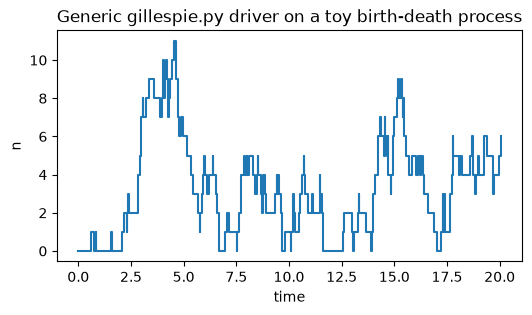

In [6]:
from gillespie import run_gillespie

class Counter:
    def __init__(self, n):
        self.n = n
    def copy(self):
        return Counter(self.n)
    def __len__(self):
        return 1  # one "agent" -- the counter itself

birth_rate, death_rate = 5.0, 0.5

def toy_rate_function(state):
    return [birth_rate, birth_rate + death_rate * state.n]  # cumulative

def birth(state, agent):
    state.n += 1

def death(state, agent):
    state.n = max(0, state.n - 1)

def stat_fn(state, stats, time):
    (stats if isinstance(stats, list) else []).append(state.n)

np.random.seed(0)
stats, times = run_gillespie(Counter(0), end_time=20, rate_function=toy_rate_function,
                              reaction_functions=[birth, death], statistic_function=stat_fn)
print(f"toy birth-death process ran {len(times)} events, final n={stats[-1]}")
assert len(stats) == len(times) and len(stats) > 0

plt.figure(figsize=(6, 3))
plt.step(times, stats, where="post")
plt.xlabel("time")
plt.ylabel("n")
plt.title("Generic gillespie.py driver on a toy birth-death process")
plt.show()

---
## 4. `run_gillespie.py` — binds the generic driver to the PRC1 `State`

- `run_gillespie_prc1(...)` builds the PRC1-specific `rate_function`/`reaction_functions` (single-attach, double-attach, detach, and optionally hop) and calls `run_gillespie(...)` from section 3. Returns `(statistics, times)` where `statistics[i] = len(state)` (PRC1 count) right after the `i`-th event.
- `run_gillespie_prc1_on_grid(...)` runs the same simulation but resamples the result onto a caller-supplied observation-time grid `times_obs` -- this is the function the SMC-ABC inference code (section 5) actually calls.

**Naming note:** `run_gillespie_prc1`'s first parameter is `initial_binding_rate_per_site`, while `run_gillespie_prc1_on_grid`'s is `initial_binding_rate` -- same quantity, different keyword name between the two wrappers. Harmless positionally, but worth knowing if you call either by keyword (see `python_version/tests/test_gillespie.py`).

ran 499 events; final PRC1 count = 50


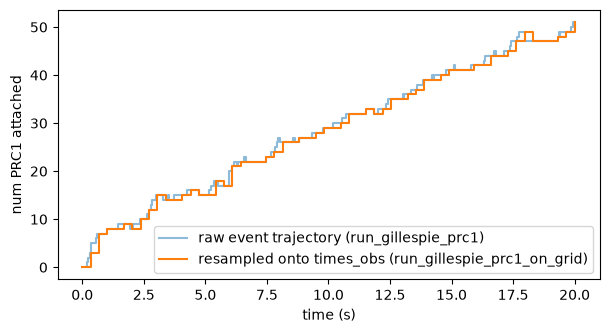

In [7]:
from run_gillespie import run_gillespie_prc1, run_gillespie_prc1_on_grid

np.random.seed(3)
statistics, times = run_gillespie_prc1(
    initial_binding_rate_per_site=4e-5, singly_bound_detachment_rate=1.0,
    base_double_attachment_rate=10.0, base_double_detachment_rate=0.1,
    end_time=20, enable_hopping="fast", max_steps=2000,
)
print(f"ran {len(times)} events; final PRC1 count = {statistics[-1]}")
assert len(statistics) == len(times) and all(s >= 0 for s in statistics)

np.random.seed(3)
times_obs = np.linspace(0, 20, 60)
y = run_gillespie_prc1_on_grid(
    initial_binding_rate=4e-5, singly_bound_detachment_rate=1.0,
    base_double_attachment_rate=10.0, base_double_detachment_rate=0.1,
    times_obs=times_obs, enable_hopping="fast", max_steps=2000,
)
assert y.shape == times_obs.shape

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.step(times, statistics, where="post", alpha=0.5, label="raw event trajectory (run_gillespie_prc1)")
ax.step(times_obs, y, where="post", label="resampled onto times_obs (run_gillespie_prc1_on_grid)")
ax.set_xlabel("time (s)")
ax.set_ylabel("num PRC1 attached")
ax.legend()
plt.show()

---
## 5. `smc-abc.py` — SMC-ABC parameter inference

Sequential Monte Carlo Approximate Bayesian Computation: instead of an exact likelihood, we simulate the model at candidate parameter vectors `theta` (via `simulate_one`, which wraps `run_gillespie_prc1_on_grid` from section 4) and keep candidates whose simulated summary statistics (`summarize_paths`: per-timepoint mean + variance across replicate runs) are close enough (within a shrinking `epsilon`) to the observed data's summary. `smc_abc_prc1` runs this over `G` generations, each tightening `epsilon` and re-proposing particles from a weighted Gaussian mixture around the previous generation.

`theta` here is the 4-vector `[initial_binding_rate, singly_bound_detachment_rate, base_double_attachment_rate, base_double_detachment_rate]` -- matching `run_gillespie_prc1_on_grid`'s real signature.

### Critical bug #2 (fixed): `simulate_one`'s parameter contract
Before the fix, `simulate_one` called `run_gillespie_prc1_on_grid(..., k0=theta[2], ...)` -- a keyword that doesn't exist on that function (a leftover from an older, unrelated 3-parameter lumped model used in `wrapper.ipynb`). Every call into `smc_abc_prc1` raised `TypeError` immediately. The cells below are the same pipeline the old, broken `python_version/test.ipynb` attempted -- they now run end to end.

`smc-abc.py` has a hyphen in its filename, so it can't be `import`ed normally -- it's loaded here via `importlib`, same as `python_version/tests/conftest.py` does for the pytest suite.

In [8]:
def _load_smc_abc():
    spec = importlib.util.spec_from_file_location("smc_abc", PYTHON_VERSION_DIR / "smc-abc.py")
    module = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(module)
    return module

smc_abc = _load_smc_abc()

theta_true = np.array([4e-5, 1.0, 10.0, 0.1])
param_names = [
    "initial_binding_rate",
    "singly_bound_detachment_rate",
    "base_double_attachment_rate",
    "base_double_detachment_rate",
]

y_test = smc_abc.simulate_one(theta_true, np.linspace(0, 20, 10), seed=0)
print("simulate_one output shape:", y_test.shape, "(matches times_obs -- signature is correct)")
assert y_test.shape == (10,)

simulate_one output shape: (10,) (matches times_obs -- signature is correct)


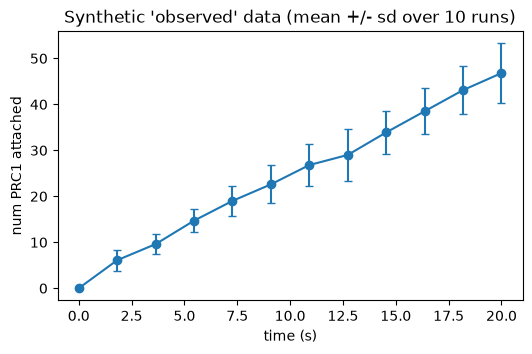

eps history (should shrink): [57.18, 54.84]


In [9]:
times_obs_smc = np.linspace(0.0, 20.0, 12)
y_obs = np.array([smc_abc.simulate_one(theta_true, times_obs_smc, seed=s) for s in range(10)])

plt.figure(figsize=(6, 3.5))
plt.errorbar(times_obs_smc, y_obs.mean(axis=0), yerr=y_obs.std(axis=0), fmt="o-", capsize=3)
plt.xlabel("time (s)")
plt.ylabel("num PRC1 attached")
plt.title("Synthetic 'observed' data (mean +/- sd over 10 runs)")
plt.show()

phi_mu = np.log(theta_true)
phi_sd = np.full(4, 0.4)

result = smc_abc.smc_abc_prc1(
    times_obs=times_obs_smc, y_obs=y_obs, phi_mu=phi_mu, phi_sd=phi_sd,
    P=15, G=2, pool=80, n_reps=2, eps_quantile=70.0, cov_scale=1.5,
    seed=7, n_jobs=-1, batch_factor=2,
)

assert result.particles_phi.shape == (15, 4)
assert np.isclose(result.weights.sum(), 1.0)
print("eps history (should shrink):", [round(e, 2) for e in result.eps_history])

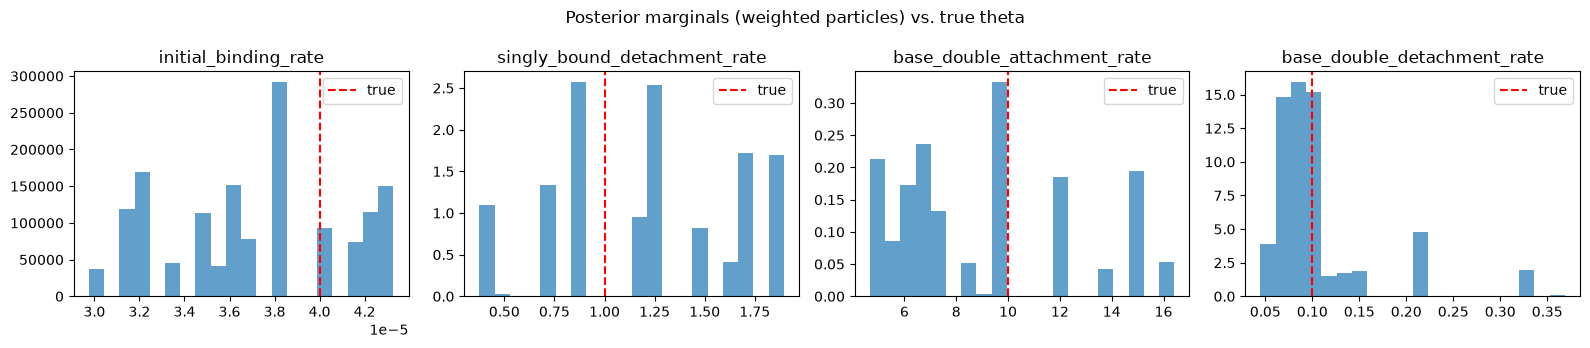

In [10]:
theta_particles = np.exp(result.particles_phi)
w = result.weights

fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
for j, (ax, name) in enumerate(zip(axes, param_names)):
    ax.hist(theta_particles[:, j], bins=20, weights=w, density=True, alpha=0.7)
    ax.axvline(theta_true[j], color="red", linestyle="--", label="true")
    ax.set_title(name)
    ax.legend()
fig.suptitle("Posterior marginals (weighted particles) vs. true theta")
plt.tight_layout()
plt.show()

---
## Summary

Every code cell above ran an `assert` -- if this notebook executed top to bottom without error, the walkthrough's claims about `Prc1`, `State`, `gillespie.py`, `run_gillespie.py`, and `smc-abc.py` all hold, and both fixed Critical bugs stayed fixed. For automated/CI use, run the equivalent checks with:
```bash
pip install -r requirements.txt
pytest
```
For the full severity-graded list of remaining findings (including the two guideline gaps -- multilane support and distance-decaying steric interference -- that this notebook does *not* cover since they're not yet implemented), see `documentation/database_structure_review.md`.

In [1]:
def largest_component_at_least_t(G, t):
    n = len(G)
    visited = [False] * n
    largest_size = 0

    for start in range(n):
        if not visited[start]:
            stack = [start]
            visited[start] = True
            size = 0

            while stack:
                v = stack.pop()
                size += 1

                for u in G[v]:
                    if not visited[u]:
                        visited[u] = True
                        stack.append(u)

            largest_size = max(largest_size, size)

    return 1 if largest_size >= t else 0

In [2]:
"""
Programming Assignment: Connected Components of Random Graphs (Erdos-Renyi)

Implements:
  1. generate_random_graph(n, p) - builds G(n,p) as an adjacency list
  2. has_large_component(G, n, t) - BFS/DFS-based connected-component sizing,
     returns 1 if some component has >= t vertices, else 0
     (plus a helper get_component(G, start, visited) that returns the actual
      list of nodes in a component, used for the self-test described in the
      assignment: no double counting, size matches len(list), etc.)
  3. Experiment over c in [0.2, 3.0] step 0.2, n = 40, p = c/n, 500 trials
     per c, t = 30. Plots percentage of graphs with a component >= t vs c.
"""

import random
from collections import deque
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt


# ---------------------------------------------------------------------------
# 1. Generate a random graph G(n, p)
# ---------------------------------------------------------------------------
def generate_random_graph(n, p):
    """
    Build an Erdos-Renyi random graph G(n, p).

    Input:  n > 1 (int), p in [0, 1] (float)
    Output: adjacency list, a dict: {vertex: set(neighbors)}
            for each pair i < j, edge (i, j) is included independently
            with probability p.
    """
    assert n > 1
    G = {i: set() for i in range(n)}
    for i in range(n):
        for j in range(i + 1, n):
            q = random.random()      # uniform in [0, 1)
            if q < p:
                G[i].add(j)
                G[j].add(i)
    return G


# ---------------------------------------------------------------------------
# 2. Connected components via BFS, each vertex visited exactly once
# ---------------------------------------------------------------------------
def get_component(G, start, visited):
    """
    BFS from `start`. Marks visited vertices in the `visited` set (in place)
    and returns the list of vertices in start's connected component.
    Each vertex is added to the queue / output list at most once.
    """
    comp = [start]
    visited.add(start)
    q = deque([start])
    while q:
        u = q.popleft()
        for v in G[u]:
            if v not in visited:
                visited.add(v)
                comp.append(v)
                q.append(v)
    return comp


def has_large_component(G, n, t):
    """
    Input:  graph G (adjacency list over vertices 0..n-1), threshold t
    Output: 1 if G has a connected component with >= t vertices, else 0

    Runs a full BFS/DFS partition of the graph: every vertex is visited
    exactly once overall (not once per component-start), giving O(n + m)
    total time, not O(n * (n + m)).
    """
    visited = set()
    max_size = 0
    for v in range(n):
        if v not in visited:
            comp = get_component(G, v, visited)
            # Self-check (as suggested in the assignment): no duplicates,
            # and size of the list equals the component size.
            assert len(comp) == len(set(comp)), "duplicate node in component!"
            assert len(comp) <= n, "component larger than graph!"
            max_size = max(max_size, len(comp))
    return 1 if max_size >= t else 0


# ---------------------------------------------------------------------------
# Self-test (sanity check, matches the assignment's suggested test)
# ---------------------------------------------------------------------------
def _self_test():
    random.seed(0)
    for _ in range(200):
        n = random.randint(2, 60)
        p = random.random()
        G = generate_random_graph(n, p)
        visited = set()
        total = 0
        for v in range(n):
            if v not in visited:
                comp = get_component(G, v, visited)
                assert len(comp) == len(set(comp))
                total += len(comp)
        assert total == n, f"components did not partition all {n} vertices (got {total})"
    print("Self-test passed: components partition all vertices with no double-counting.")


# ---------------------------------------------------------------------------
# 3. Experiment: percentage of graphs with a component of size >= t vs c
# ---------------------------------------------------------------------------
def run_experiment(n=40, t=30, num_trials=500, c_values=None, seed=1):
    if c_values is None:
        c_values = [round(0.2 * k, 1) for k in range(1, 16)]  # 0.2 .. 3.0

    random.seed(seed)
    percentages = []
    for c in c_values:
        p = c / n
        count = 0
        for _ in range(num_trials):
            G = generate_random_graph(n, p)
            count += has_large_component(G, n, t)
        pct = 100.0 * count / num_trials
        percentages.append(pct)
        print(f"c = {c:>4.1f}  p = {p:.5f}  -> {pct:6.2f}% of {num_trials} graphs "
              f"have a component with >= {t} vertices")
    return c_values, percentages


def plot_results(c_values, percentages, t, n, num_trials, outpath):
    fig, ax = plt.subplots(figsize=(7, 5), dpi=150)
    ax.plot(c_values, percentages, marker="o", color="#4C72B0", linewidth=2)
    ax.axvline(1.0, color="#C44E52", linestyle="--", linewidth=1,
                label="c = 1 (theoretical threshold)")
    ax.set_xlabel("c  (p = c / n)")
    ax.set_ylabel(f"% of graphs with a component of size >= {t}")
    ax.set_title(f"Giant Component Emergence in G(n, p),  n = {n},  {num_trials} trials per c")
    ax.set_ylim(-5, 105)
    ax.grid(True, alpha=0.3)
    ax.legend()
    fig.tight_layout()
    fig.savefig(outpath)
    print(f"Saved plot to {outpath}")


if __name__ == "__main__":
    _self_test()
    c_values, percentages = run_experiment()
    plot_results(c_values, percentages, t=30, n=40, num_trials=500,
                 outpath="giant_component_plot.png")

Self-test passed: components partition all vertices with no double-counting.
c =  0.2  p = 0.00500  ->   0.00% of 500 graphs have a component with >= 30 vertices
c =  0.4  p = 0.01000  ->   0.00% of 500 graphs have a component with >= 30 vertices
c =  0.6  p = 0.01500  ->   0.00% of 500 graphs have a component with >= 30 vertices
c =  0.8  p = 0.02000  ->   0.00% of 500 graphs have a component with >= 30 vertices
c =  1.0  p = 0.02500  ->   0.00% of 500 graphs have a component with >= 30 vertices
c =  1.2  p = 0.03000  ->   1.40% of 500 graphs have a component with >= 30 vertices
c =  1.4  p = 0.03500  ->   9.60% of 500 graphs have a component with >= 30 vertices
c =  1.6  p = 0.04000  ->  25.00% of 500 graphs have a component with >= 30 vertices
c =  1.8  p = 0.04500  ->  45.40% of 500 graphs have a component with >= 30 vertices
c =  2.0  p = 0.05000  ->  68.20% of 500 graphs have a component with >= 30 vertices
c =  2.2  p = 0.05500  ->  82.80% of 500 graphs have a component with >= 